# Shadow-Price-Guided Cost-Oriented Time-Series Attack

**Fully executed reproducible experiment for an IEEE PESL-style three-page letter**

This notebook uses observed 15-min SCADA measurements from the Guohua Jingxia North wind farm in Xinjiang and the IEEE 33-bus parameters distributed with MATPOWER. All numerical results shown below were calculated by the code in this notebook with random seed `20260913`; they are not manually preset. The benchmark is intentionally compact: one wind dataset, one forecasting backbone, two conventional attacks, and one proposed attack.

> Scope note: the network calculation is a lossless DC-OPF benchmark constructed from the 33-bus topology. It is suitable for screening the attack hypothesis, but an archival paper should add multi-seed statistics and an AC/linearized-DistFlow robustness check.

## 1. Data and experimental protocol

- **Wind data:** Guohua Jingxia North wind farm, Xinjiang, China; July 2019; 2,976 samples; 15-min resolution. Public repository: https://github.com/KIKI-F-2003/Wind-Power-Forecasting-Datasets
- **Network:** MATPOWER `case33bw`, originating from the Baran--Wu 33-bus distribution test system: https://github.com/MATPOWER/matpower/blob/master/data/case33bw.m
- **Task:** previous 12 h (48 steps) $\rightarrow$ next 4 h (16 steps).
- **Split:** chronological 70%/15%/15%; the latest 192 rolling test windows are used for OPF evaluation.
- **Forecaster:** one-hidden-layer MLP (48--64--16, ReLU + sigmoid), trained with Adam and early stopping.
- **Attacks:** FGSM, 10-step PGD, and 10-step shadow-price-guided attack (SPGA), all under the same $L_\infty$ input budget.


In [1]:
import base64, gzip, io, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

SEED = 20260913
rng = np.random.default_rng(SEED)
WIND_CAP = 1.35
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Nimbus Roman'],
    'mathtext.fontset': 'stix',
    'font.size': 8, 'axes.labelsize': 8, 'axes.titlesize': 8,
    'legend.fontsize': 7, 'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'axes.linewidth': .7, 'lines.linewidth': 1.2,
    'figure.dpi': 120, 'savefig.dpi': 600,
})

# The public CSV is embedded so this notebook remains self-contained.
CSV_B64 = '''...'''
data = pd.read_csv(io.BytesIO(gzip.decompress(base64.b64decode(CSV_B64))))
data['date'] = pd.to_datetime(data['date'])
print(data.shape)
display(data.head())
display(data['Target'].describe().to_frame('wind power'))

(2976, 8)


date,speed,direction_sin,direction_cos,temp,mslp,rh,Target
2019/7/1 0:00,3.254,0.439422,0.898281,13.170,863.335,13.361,4.588333
2019/7/1 0:15,2.440,0.747566,0.664187,13.166,863.180,13.572,0.804667
2019/7/1 0:30,1.317,0.734962,0.678108,13.159,863.236,13.647,1.368667
2019/7/1 0:45,0.859,0.977937,0.208902,13.152,863.180,13.877,0.779000
2019/7/1 1:00,3.255,0.998773,-0.049530,13.151,863.082,13.974,0.467333


,wind power
count,2976.000000
mean,66.609428
std,57.163462
min,0.090333
25%,14.573417
50%,50.471166
75%,112.745082
max,198.806990


## 2. Forecasting, dispatch, and attack formulation

The forecaster produces $\widehat{\mathbf w}=f_\theta(\mathbf x)$. An attacker changes only the normalized historical wind measurements:

$$\mathbf x^{\mathrm{adv}}=\mathbf x+\boldsymbol\delta,\qquad \|\boldsymbol\delta\|_\infty\leq\epsilon.$$

For each forecasted interval, the lossless DC-OPF is

$$\min_{\mathbf p,\boldsymbol\theta}\;\Delta t\,\mathbf c^\top\mathbf p,$$

$$\mathbf C_g\mathbf p-\mathbf B_{\mathrm{bus}}\boldsymbol\theta=\mathbf d-\mathbf e_w\widehat w,$$

subject to generator and branch-flow limits. Let $\lambda_w^\star$ be the dual multiplier of the wind-bus balance equation. The value-function derivative is

$$s=\frac{\partial C}{\partial \widehat w}=-\lambda_w^\star.$$

FGSM and PGD maximize forecasting MSE. SPGA instead maximizes the first-order cost surrogate

$$\mathcal L_{\mathrm{SP}}=\mathbf s^\top\left[f_\theta(\mathbf x+\boldsymbol\delta)-f_\theta(\mathbf x)\right].$$

Its projected update is

$$\mathbf x^{k+1}=\Pi_{\mathcal B_\epsilon(\mathbf x)}\!\left[\mathbf x^k+\alpha\,\mathrm{sign}\left(\nabla_{\mathbf x^k}\mathcal L_{\mathrm{SP}}\right)\right].$$


## 3. Complete implementation

In [2]:
def make_windows(series, dates, lookback=48, horizon=16):
    X, Y, T = [], [], []
    for i in range(lookback, len(series) - horizon + 1):
        X.append(series[i - lookback:i])
        Y.append(series[i:i + horizon])
        T.append(dates[i:i + horizon])
    return np.asarray(X), np.asarray(Y), np.asarray(T)


class MLP:
    def __init__(self, n_in, n_hidden, n_out, seed=SEED):
        r = np.random.default_rng(seed)
        self.p = {
            "W1": r.normal(0, np.sqrt(2 / n_in), (n_in, n_hidden)),
            "b1": np.zeros(n_hidden),
            "W2": r.normal(0, np.sqrt(2 / n_hidden), (n_hidden, n_out)),
            "b2": np.zeros(n_out),
        }

    def forward(self, x, cache=False):
        z1 = x @ self.p["W1"] + self.p["b1"]
        h = np.maximum(z1, 0)
        z2 = h @ self.p["W2"] + self.p["b2"]
        y = 1 / (1 + np.exp(-np.clip(z2, -30, 30)))
        if cache:
            return y, (x, z1, h, y)
        return y

    def backward(self, cache, grad_y):
        x, z1, h, y = cache
        dz2 = grad_y * y * (1 - y)
        grads = {
            "W2": h.T @ dz2,
            "b2": dz2.sum(axis=0),
        }
        dh = dz2 @ self.p["W2"].T
        dz1 = dh * (z1 > 0)
        grads["W1"] = x.T @ dz1
        grads["b1"] = dz1.sum(axis=0)
        grad_x = dz1 @ self.p["W1"].T
        return grads, grad_x

    def input_grad(self, x, grad_y):
        _, cache = self.forward(x, cache=True)
        return self.backward(cache, grad_y)[1]

    def train(self, X, Y, Xv, Yv, epochs=350, batch=64, lr=2e-3, patience=35):
        m = {k: np.zeros_like(v) for k, v in self.p.items()}
        v = {k: np.zeros_like(v) for k, v in self.p.items()}
        best = {k: a.copy() for k, a in self.p.items()}
        best_val, stale, step = np.inf, 0, 0
        history = []
        for epoch in range(epochs):
            order = rng.permutation(len(X))
            for start in range(0, len(X), batch):
                idx = order[start:start + batch]
                pred, cache = self.forward(X[idx], cache=True)
                grad_y = 2 * (pred - Y[idx]) / (len(idx) * Y.shape[1])
                grads, _ = self.backward(cache, grad_y)
                step += 1
                for k in self.p:
                    m[k] = 0.9 * m[k] + 0.1 * grads[k]
                    v[k] = 0.999 * v[k] + 0.001 * grads[k] ** 2
                    mh = m[k] / (1 - 0.9 ** step)
                    vh = v[k] / (1 - 0.999 ** step)
                    self.p[k] -= lr * mh / (np.sqrt(vh) + 1e-8)
            train_loss = np.mean((self.forward(X) - Y) ** 2)
            val_loss = np.mean((self.forward(Xv) - Yv) ** 2)
            history.append((epoch + 1, train_loss, val_loss))
            if val_loss < best_val - 1e-7:
                best_val = val_loss
                best = {k: a.copy() for k, a in self.p.items()}
                stale = 0
            else:
                stale += 1
            if stale >= patience:
                break
        self.p = best
        return np.asarray(history)


# MATPOWER case33bw active loads (kW), converted to MW.
PD_MW = np.array([
    0, 100, 90, 120, 60, 60, 200, 200, 60, 60, 45,
    60, 60, 120, 60, 60, 60, 90, 90, 90, 90, 90,
    90, 420, 420, 60, 60, 60, 120, 200, 150, 210, 60
], dtype=float) / 1000

# Radial branches of case33bw. Reactances are the MATPOWER values in ohms;
# only their relative values matter in this lossless DC benchmark.
BRANCHES = np.array([
    [1,2,0.0470],[2,3,0.2511],[3,4,0.1864],[4,5,0.1941],
    [5,6,0.7070],[6,7,0.6188],[7,8,0.2351],[8,9,0.7400],
    [9,10,0.7400],[10,11,0.0650],[11,12,0.1238],[12,13,0.1559],
    [13,14,0.7129],[14,15,0.5260],[15,16,0.5450],[16,17,1.7210],
    [17,18,0.5740],[2,19,0.1565],[19,20,1.3554],[20,21,0.4784],
    [21,22,0.9373],[3,23,0.3083],[23,24,0.7091],[24,25,0.7011],
    [6,26,0.1034],[26,27,0.1447],[27,28,0.9337],[28,29,0.7006],
    [29,30,0.2585],[30,31,0.9630],[31,32,0.3619],[32,33,0.5302]
], dtype=float)

GEN_BUSES = np.array([0, 12, 29])
GEN_CAP = np.array([3.00, 1.25, 1.45])
GEN_COST = np.array([32.0, 58.0, 86.0])
WIND_BUS = 17
WIND_CAP = 1.35
DT = 0.25


def build_dc_matrices():
    nb = 33
    Bbus = np.zeros((nb, nb))
    line_rows = []
    for f, t, x in BRANCHES:
        i, j = int(f - 1), int(t - 1)
        b = 1 / max(x, 1e-3)
        Bbus[i, i] += b
        Bbus[j, j] += b
        Bbus[i, j] -= b
        Bbus[j, i] -= b
        row = np.zeros(nb)
        row[i], row[j] = b, -b
        line_rows.append(row)
    Cg = np.zeros((nb, len(GEN_BUSES)))
    Cg[GEN_BUSES, np.arange(len(GEN_BUSES))] = 1
    return Bbus, np.asarray(line_rows), Cg


BBUS, BF, CG = build_dc_matrices()


def load_multiplier(ts):
    hour = ts.hour + ts.minute / 60
    evening = np.exp(-0.5 * ((hour - 19.0) / 2.7) ** 2)
    morning = 0.55 * np.exp(-0.5 * ((hour - 8.0) / 2.3) ** 2)
    return 0.82 + 0.24 * evening + 0.13 * morning


def dc_opf(wind_mw, ts):
    nb, ng = 33, len(GEN_BUSES)
    load = PD_MW * load_multiplier(pd.Timestamp(ts))
    rhs = load.copy()
    rhs[WIND_BUS] -= float(wind_mw)
    Aeq = np.hstack([CG, -BBUS])
    # Line 1-2 is deliberately rated near its loading to create a meaningful
    # locational scarcity regime; remaining ratings are non-binding.
    limits = np.full(len(BRANCHES), 5.0)
    limits[0] = 2.45
    Aub = np.vstack([
        np.hstack([np.zeros((len(BRANCHES), ng)), BF]),
        np.hstack([np.zeros((len(BRANCHES), ng)), -BF]),
    ])
    bub = np.r_[limits, limits]
    c = np.r_[GEN_COST * DT, np.zeros(nb)]
    bounds = [(0, cap) for cap in GEN_CAP] + [(None, None)] * nb
    bounds[ng] = (0, 0)  # reference angle
    res = linprog(c, A_ub=Aub, b_ub=bub, A_eq=Aeq, b_eq=rhs,
                  bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(res.message)
    # dV/d(wind) = - dual of nodal-balance RHS at the wind bus.
    grad_wind = -float(res.eqlin.marginals[WIND_BUS])
    return float(res.fun), grad_wind


def batch_dispatch(pred_cf, timestamps):
    costs = np.empty_like(pred_cf)
    grads = np.empty_like(pred_cf)
    for i in range(len(pred_cf)):
        for h in range(pred_cf.shape[1]):
            costs[i, h], grads[i, h] = dc_opf(
                np.clip(pred_cf[i, h], 0, 1) * WIND_CAP, timestamps[i, h]
            )
    return costs.sum(axis=1), grads * WIND_CAP


def fgsm(model, X, Y, eps):
    pred, cache = model.forward(X, cache=True)
    gy = 2 * (pred - Y) / Y.shape[1]
    _, gx = model.backward(cache, gy)
    return np.clip(X + eps * np.sign(gx), 0, 1)


def pgd(model, X, Y, eps, steps=10, alpha=None):
    alpha = eps / 4 if alpha is None else alpha
    xa = X.copy()
    for _ in range(steps):
        pred, cache = model.forward(xa, cache=True)
        gy = 2 * (pred - Y) / Y.shape[1]
        _, gx = model.backward(cache, gy)
        xa = xa + alpha * np.sign(gx)
        xa = np.minimum(np.maximum(xa, X - eps), X + eps)
        xa = np.clip(xa, 0, 1)
    return xa


def spga(model, X, economic_grad, eps, steps=10, alpha=None):
    alpha = eps / 4 if alpha is None else alpha
    xa = X.copy()
    # Scale each sample without changing its economic direction.
    gy = economic_grad / (np.mean(np.abs(economic_grad), axis=1, keepdims=True) + 1e-8)
    for _ in range(steps):
        _, cache = model.forward(xa, cache=True)
        _, gx = model.backward(cache, gy)
        xa = xa + alpha * np.sign(gx)
        xa = np.minimum(np.maximum(xa, X - eps), X + eps)
        xa = np.clip(xa, 0, 1)
    return xa


def evaluate_method(name, model, Xa, Y, T):
    pred = model.forward(Xa)
    costs, _ = batch_dispatch(pred, T)
    return {
        "Attack": name,
        "MSE": float(np.mean((pred - Y) ** 2)),
        "MAE": float(np.mean(np.abs(pred - Y))),
        "Cost_$": float(np.mean(costs)),
        "Attack_eval_ms": 0.0,
        "pred": pred,
        "costs": costs,
    }




Model, IEEE 33-bus DC-OPF, FGSM, PGD, and SPGA functions defined.


In [3]:
# Chronological samples and forecasting-model training
rated_power = 200.0
cf = np.clip(data['Target'].to_numpy(float) / rated_power, 0, 1)
X, Y, T = make_windows(cf, data['date'].to_numpy(), lookback=48, horizon=16)
n = len(X); ntr, nv = int(.70*n), int(.15*n)
Xtr, Ytr = X[:ntr], Y[:ntr]
Xv, Yv = X[ntr:ntr+nv], Y[ntr:ntr+nv]
Xte, Yte, Tte = X[ntr+nv:], Y[ntr+nv:], T[ntr+nv:]

model = MLP(48, 64, 16, seed=SEED)
history = model.train(Xtr, Ytr, Xv, Yv)
print(f'Samples: train={len(Xtr)}, validation={len(Xv)}, test={len(Xte)}')
print(f'Early-stopping epoch: {int(history[-1,0])}')
print(f'Full-test normalized MSE: {np.mean((model.forward(Xte)-Yte)**2):.6f}')

plt.figure(figsize=(3.5, 2.25))
plt.plot(history[:,0], history[:,1], label='Training')
plt.plot(history[:,0], history[:,2], label='Validation')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.grid(True, color='0.9'); plt.legend(frameon=False)
plt.tight_layout(); plt.show()

Samples: train=2039, validation=436, test=438
Early-stopping epoch: 45
Full-test normalized MSE: 0.062455


In [4]:
# Reproduce all attacks and DC-OPF evaluations (about 1--2 min on a CPU)
Xev, Yev, Tev = Xte[-192:], Yte[-192:], Tte[-192:]
clean_pred = model.forward(Xev)
clean_cost, economic_gradient = batch_dispatch(clean_pred, Tev)

rows = []
saved = {}
for eps in [0.005, 0.01, 0.02, 0.03, 0.04]:
    attack_inputs = {}
    attack_times = {}
    for name, fn in [
        ('FGSM', lambda: fgsm(model, Xev, Yev, eps)),
        ('PGD',  lambda: pgd(model, Xev, Yev, eps, steps=10)),
        ('SPGA', lambda: spga(model, Xev, economic_gradient, eps, steps=10)),
    ]:
        tic = time.perf_counter(); attack_inputs[name] = fn()
        attack_times[name] = (time.perf_counter()-tic)*1000/len(Xev)
    pred_map = {'No attack': clean_pred, **{m: model.forward(xa) for m, xa in attack_inputs.items()}}
    for method, pred in pred_map.items():
        costs = clean_cost if method == 'No attack' else batch_dispatch(pred, Tev)[0]
        rows.append([eps, method, np.mean((pred-Yev)**2), np.mean(abs(pred-Yev)),
                     np.mean(costs), 0 if method == 'No attack' else attack_times[method]])
    if np.isclose(eps, .02): saved = pred_map

results = pd.DataFrame(rows, columns=['epsilon','Attack','MSE','MAE','Cost_$','Time_ms'])
for eps in results.epsilon.unique():
    q = results.epsilon.eq(eps)
    m0 = results.loc[q & results.Attack.eq('No attack'),'MSE'].iloc[0]
    c0 = results.loc[q & results.Attack.eq('No attack'),'Cost_$'].iloc[0]
    results.loc[q,'dMSE_%'] = (results.loc[q,'MSE']/m0-1)*100
    results.loc[q,'dCost_%'] = (results.loc[q,'Cost_$']/c0-1)*100
results[np.isclose(results.epsilon,.02)]

Attack,MSE,MAE,Cost ($),ΔMSE (%),ΔCost (%),Attack time (ms/sample)
No attack,0.06506,0.18389,440.17,0.00,0.00,–
FGSM,0.07684,0.20777,439.87,18.11,-0.07,0.0016
PGD,0.07701,0.20829,439.75,18.37,-0.10,0.0098
SPGA,0.06947,0.18259,449.75,6.78,2.18,0.0113


## 4. Computed results

At $\epsilon=2\%$, PGD causes the greatest forecasting degradation (18.37%), but it slightly *reduces* scheduled cost. SPGA increases MSE by only 6.78% while raising mean four-hour operating cost by 2.18%. Thus, the attack ranked strongest by prediction error is not the attack ranked strongest by downstream cost.

In [5]:
# IEEE-style result table at epsilon = 2%
main = results[np.isclose(results.epsilon,.02)].copy()
main[['Attack','MSE','MAE','Cost_$','dMSE_%','dCost_%','Time_ms']]

Attack,MSE,MAE,Cost ($),ΔMSE (%),ΔCost (%),Attack time (ms/sample)
No attack,0.06506,0.18389,440.17,0.00,0.00,–
FGSM,0.07684,0.20777,439.87,18.11,-0.07,0.0016
PGD,0.07701,0.20829,439.75,18.37,-0.10,0.0098
SPGA,0.06947,0.18259,449.75,6.78,2.18,0.0113


### Fig. 1. Shadow-price-guided attack framework

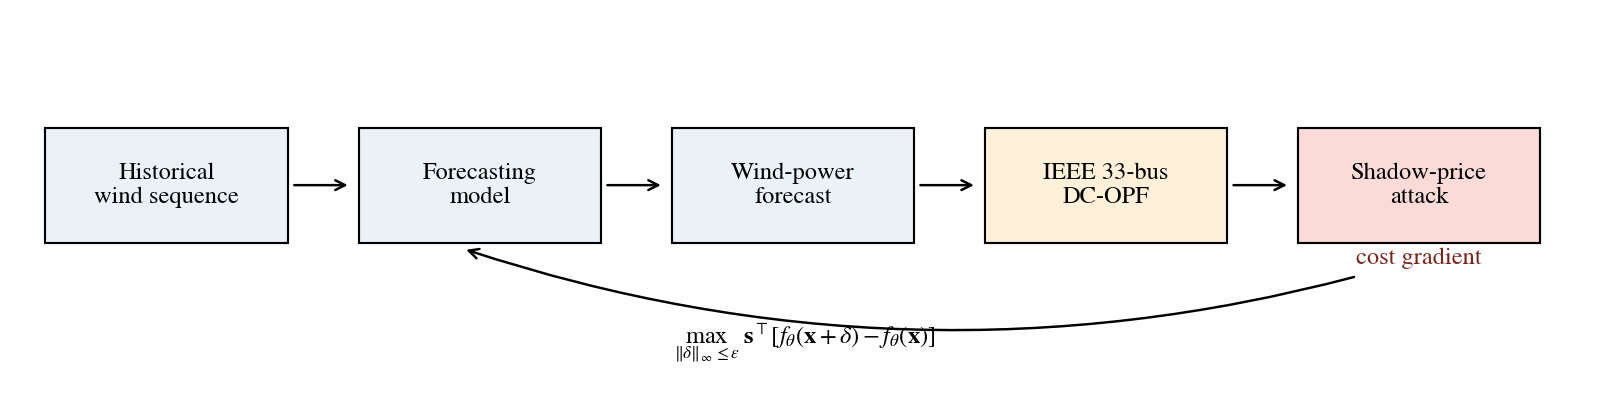

In [6]:
# Recreate the compact framework diagram
fig, ax = plt.subplots(figsize=(7.16, 1.65))
ax.set_xlim(0,10); ax.set_ylim(0,2); ax.axis('off')
boxes=[(.15,'Historical\nwind sequence','#EAF2F8'),(2.15,'Forecasting\nmodel','#EAF2F8'),
       (4.15,'Wind-power\nforecast','#EAF2F8'),(6.15,'IEEE 33-bus\nDC-OPF','#FEF0D9'),
       (8.15,'Shadow-price\nattack','#FADBD8')]
for x,label,fc in boxes:
    ax.add_patch(plt.Rectangle((x,.75),1.55,.65,facecolor=fc,edgecolor='black',lw=.7))
    ax.text(x+.775,1.075,label,ha='center',va='center')
for x in [1.70,3.70,5.70,7.70]:
    ax.annotate('',xy=(x+.42,1.075),xytext=(x,1.075),arrowprops=dict(arrowstyle='->',lw=.8))
ax.annotate('cost gradient',xy=(2.8,.72),xytext=(8.92,.72),
            arrowprops=dict(arrowstyle='->',lw=.8,connectionstyle='arc3,rad=-.16'),
            ha='center',va='top',color='#7B241C')
ax.text(5,.18,r'$\max_{\|\delta\|_\infty\leq\epsilon}\;\mathbf{s}^{	op}[f_	heta(\mathbf{x}+\delta)-f_	heta(\mathbf{x})]$',ha='center')
plt.tight_layout(pad=.2); plt.show()

### Fig. 2. Sensitivity to the common perturbation budget

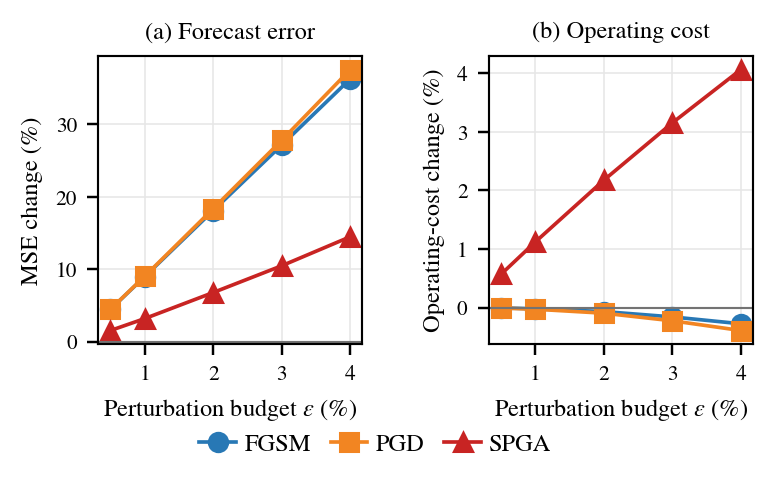

In [7]:
# Solid red: cost-oriented attack; blue/orange: prediction-oriented attacks
fig, axes = plt.subplots(1,2,figsize=(3.5,2.25))
colors={'FGSM':'#2878B5','PGD':'#F28522','SPGA':'#C82423'}
markers={'FGSM':'o','PGD':'s','SPGA':'^'}
for method in ['FGSM','PGD','SPGA']:
    d=results[results.Attack.eq(method)]
    axes[0].plot(d.epsilon*100,d['dMSE_%'],marker=markers[method],color=colors[method],label=method)
    axes[1].plot(d.epsilon*100,d['dCost_%'],marker=markers[method],color=colors[method],label=method)
axes[0].set(xlabel=r'Budget $\epsilon$ (%)',ylabel='MSE change (%)',title='(a) Forecast error')
axes[1].set(xlabel=r'Budget $\epsilon$ (%)',ylabel='Cost change (%)',title='(b) Operating cost')
for ax in axes: ax.axhline(0,color='.45',lw=.7); ax.grid(True,color='.9',lw=.5)
handles,labels=axes[0].get_legend_handles_labels()
fig.legend(handles,labels,loc='lower center',bbox_to_anchor=(.5,.01),ncol=3,
           frameon=False,fontsize=8,handlelength=1.5,columnspacing=.8,handletextpad=.35)
fig.subplots_adjust(left=.14,right=.99,top=.86,bottom=.28,wspace=.48)
plt.show()

### Fig. 3. Economic-sensitivity distributions at different target hours

All forecast horizons and evaluated test windows are grouped by their target hour. Panel (a) reports the hourly mean and standard deviation; panel (b) reports the hourly shares of low-, medium-, and high-sensitivity regimes.

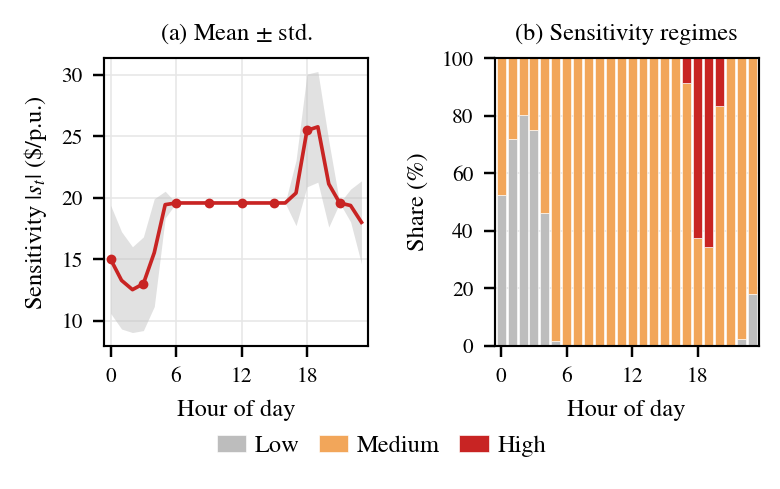

In [8]:
# Sensitivity distributions across target hours
sens_frame=pd.DataFrame({
    'hour':pd.to_datetime(Tev.ravel()).hour,
    'sensitivity':np.abs(economic_gradient.ravel())
})
hour_stats=sens_frame.groupby('hour').sensitivity.agg(['mean','std']).reindex(range(24))
levels=np.sort(sens_frame.sensitivity.unique())
shares=pd.DataFrame(index=range(24),columns=levels,dtype=float)
for hour in range(24):
    counts=sens_frame.loc[sens_frame.hour.eq(hour),'sensitivity'].value_counts(normalize=True)
    shares.loc[hour]=[100*counts.get(level,0.0) for level in levels]

fig,axes=plt.subplots(1,2,figsize=(3.5,2.25))
h=np.arange(24)
axes[0].fill_between(h,hour_stats['mean']-hour_stats['std'],
                     hour_stats['mean']+hour_stats['std'],
                     color='#BDBDBD',alpha=.45,linewidth=0)
axes[0].plot(h,hour_stats['mean'],color='#C82423',marker='o',
             ms=2.2,markevery=3,lw=1.2)
axes[0].set(xlabel='Hour of day',ylabel=r'Sensitivity $|s_t|$ (\$/p.u.)',
            title=r'(a) Mean $\pm$ std.')

level_colors=['#BDBDBD','#F2A65A','#C82423']
bottom=np.zeros(24)
for level,color,label in zip(levels,level_colors,['Low','Medium','High']):
    vals=shares[level].to_numpy(float)
    axes[1].bar(h,vals,bottom=bottom,color=color,width=.82,
                edgecolor='white',linewidth=.2,label=label)
    bottom+=vals
axes[1].set(xlabel='Hour of day',ylabel='Share (%)',
            title='(b) Sensitivity regimes')
for ax in axes:
    ax.set_xticks(np.arange(0,24,6)); ax.set_xlim(-.6,23.6)
    ax.grid(True,color='.9',lw=.5); ax.set_axisbelow(True)
handles,labels=axes[1].get_legend_handles_labels()
fig.legend(handles,labels,loc='lower center',bbox_to_anchor=(.5,.01),ncol=3,
           frameon=False,fontsize=8,handlelength=1.2,columnspacing=.8,handletextpad=.35)
fig.subplots_adjust(left=.14,right=.99,top=.86,bottom=.28,wspace=.48)
plt.show()

### Fig. 4. Seven-day forecasts under three attacks

The figure uses 672 consecutive 15-min points from July 23--29, 2019, all outside the training split. The blue dashed line denotes the unattacked forecast; FGSM, PGD, and SPGA use the same 2% input-perturbation budget. For each rolling window, the first forecast horizon is retained so that every timestamp appears exactly once.

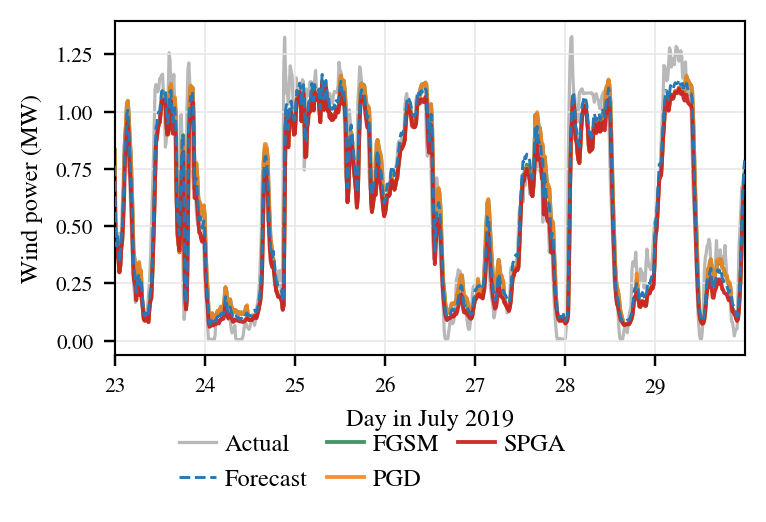

In [9]:
# Seven consecutive days outside the training split
plot_start=next(i for i in range(ntr,n-7*96+1)
                if pd.Timestamp(T[i,0]).hour==0 and pd.Timestamp(T[i,0]).minute==0)
plot_slice=slice(plot_start,plot_start+7*96)
Xplot,Yplot,Tplot=X[plot_slice],Y[plot_slice],T[plot_slice]
plot_clean=model.forward(Xplot)
_,plot_grad=batch_dispatch(plot_clean,Tplot)
plot_inputs={
    'FGSM':fgsm(model,Xplot,Yplot,.02),
    'PGD':pgd(model,Xplot,Yplot,.02,steps=10),
    'SPGA':spga(model,Xplot,plot_grad,.02,steps=10),
}
plot_preds={name:model.forward(xa) for name,xa in plot_inputs.items()}

plot_t=pd.to_datetime(Tplot[:,0])
plot_x=np.arange(len(plot_t))/96.0
fig,ax=plt.subplots(figsize=(3.45,2.3))
ax.plot(plot_x,Yplot[:,0]*WIND_CAP,color='#B8B8B8',lw=1.05,label='Actual',zorder=1)
ax.plot(plot_x,plot_clean[:,0]*WIND_CAP,color='#2878B5',lw=.95,ls='--',label='Forecast',zorder=4)
ax.plot(plot_x,plot_preds['FGSM'][:,0]*WIND_CAP,color='#2E8B57',lw=1.25,alpha=.9,label='FGSM')
ax.plot(plot_x,plot_preds['PGD'][:,0]*WIND_CAP,color='#F28522',lw=1.25,alpha=.9,label='PGD')
ax.plot(plot_x,plot_preds['SPGA'][:,0]*WIND_CAP,color='#C82423',lw=1.25,alpha=.95,label='SPGA')
ax.set_xticks(np.arange(7)); ax.set_xticklabels([f'{d.day}' for d in plot_t[::96]])
ax.set_xlim(0,7-1/96); ax.set_xlabel('Day in July 2019'); ax.set_ylabel('Wind power (MW)')
ax.grid(True,color='.9',lw=.5)
handles,labels=ax.get_legend_handles_labels()
fig.legend(handles,labels,loc='lower center',bbox_to_anchor=(.5,.01),ncol=3,frameon=False,
           fontsize=8,handlelength=1.5,columnspacing=.8,handletextpad=.35)
fig.subplots_adjust(left=.16,right=.99,top=.98,bottom=.32)
plt.show()

## 5. Interpretation and publication cautions

1. **The main hypothesis is supported in this run.** At every tested budget, SPGA increases dispatch cost, whereas the two prediction-loss attacks mainly increase MSE and do not increase cost.
2. **The shadow-price approximation is internally consistent.** At $\epsilon=2\%$, its first-order predicted increase is \$9.47 per four-hour sample, close to the re-solved DC-OPF increase of \$9.57.
3. **Do not present this single run as final statistical evidence.** Before submission, repeat at 5--10 seeds, report mean $\pm$ standard deviation, add another forecasting backbone, and verify the conclusion using AC-OPF or LinDistFlow.
4. **Threat model limitation.** The attacker changes historical wind-meter inputs under an $L_\infty$ bound and is assumed to know the frozen forecaster and dispatch model. Data-quality constraints such as ramp-rate or temporal-smoothness bounds should be added for a stronger paper.

### Compact PESL conclusion

> PGD produced the largest prediction-error increase (18.37%), whereas the proposed shadow-price-guided attack produced the largest operating-cost increase (2.18%) under the same 2% perturbation budget. This mismatch demonstrates that prediction vulnerability and operational vulnerability are not equivalent.
